In [165]:
import numpy as np
np.set_printoptions(threshold=100000, linewidth=100000)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [166]:
import datetime
def write_csv_file(y_pred :np.ndarray):
    '''Write csv file from numpy array y_pred'''
    now_string = (datetime.datetime.now()-datetime.timedelta(hours=3)).strftime("%d-%m_%H-%M-%S")
    
    output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
    output_df['%'] = y_pred#.squeeze().detach().cpu().numpy()
    output_df.to_csv("time2_trilha1_"+now_string+".csv", sep="\t", index=False)
    return output_df

In [167]:
train_df = pd.read_csv('data_train_post_n_smoothing.csv', sep="\t")
test_df = pd.read_csv('data_test_post_n_smoothing.csv', sep="\t")

PINN using two-decay format

In [168]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df.iloc[:,:-1])).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

trainDs, valDs = random_split(TensorDataset(X, y), [.8,.2])
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

Device is cuda


In [169]:
headlessmodel = nn.Sequential(
    nn.Linear(X.shape[1],128),
    nn.ReLU(),
    nn.Linear(128,32),
    nn.ReLU(),
    nn.Linear(32,5), #interpreted as A_o, A_w, T2_o, T2_w, offset
    ).to(device)

optimizer = torch.optim.Adam(headlessmodel.parameters(), lr=1e-3)

Epoch 00 | train output MSE: 0.058552 | train fit MSE: 0.254615 | val output MSE: 0.061839 | val fit MSE: 0.171853
Epoch 10 | train output MSE: 0.045896 | train fit MSE: 0.057019 | val output MSE: 0.047770 | val fit MSE: 0.056467
Epoch 20 | train output MSE: 0.044565 | train fit MSE: 0.053548 | val output MSE: 0.046099 | val fit MSE: 0.053895
Epoch 30 | train output MSE: 0.041727 | train fit MSE: 0.052031 | val output MSE: 0.042790 | val fit MSE: 0.052270
Epoch 40 | train output MSE: 0.034057 | train fit MSE: 0.049593 | val output MSE: 0.034256 | val fit MSE: 0.049653
Epoch 50 | train output MSE: 0.021210 | train fit MSE: 0.045952 | val output MSE: 0.020717 | val fit MSE: 0.045784
Epoch 60 | train output MSE: 0.017684 | train fit MSE: 0.036808 | val output MSE: 0.018103 | val fit MSE: 0.035564
Epoch 70 | train output MSE: 0.016158 | train fit MSE: 0.015648 | val output MSE: 0.015737 | val fit MSE: 0.014212
Epoch 80 | train output MSE: 0.014772 | train fit MSE: 0.003518 | val output MSE

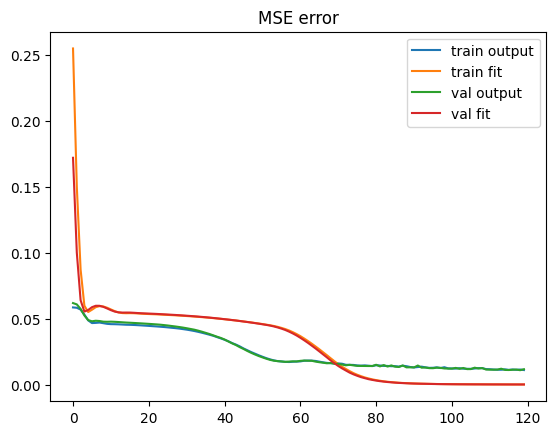

In [171]:
epochs = 120
history = []
for epoch in range(epochs):
    headlessmodel.train()
    train_loss_output, train_loss_phys = 0., 0.

    for xb, yb in train_loader:
        pre_outcome = headlessmodel(xb)
        outp1 = nn.Sigmoid()(pre_outcome[:,:2])
        outp2 = nn.functional.softplus(pre_outcome[:,2:])
        outcome = torch.cat([outp1,outp2],dim=1)
        # outcome = nn.Sigmoid()(pre_outcome)
        outcome_ext = outcome.unsqueeze(1).expand(*xb.shape,outcome.shape[-1])
        
        t_values = torch.arange(0,xb.shape[1]).unsqueeze(0).expand(xb.shape).to(device)
        loss_output = nn.MSELoss()(outcome[:,0]/(outcome[:,0]+outcome[:,1]),yb.squeeze())
        loss_phys   = nn.MSELoss()(xb,
                            outcome_ext[:,:,0]*torch.exp(-t_values/torch.clamp(outcome_ext[:,:,2], min=1e-3)) + \
                            outcome_ext[:,:,1]*torch.exp(-t_values/torch.clamp(outcome_ext[:,:,3], min=1e-3)) + \
                                  outcome_ext[:,:,4]) 
            
        optimizer.zero_grad()
        (loss_output+4*loss_phys).backward()
        optimizer.step()

        train_loss_output += loss_output.item() * xb.size(0)
        train_loss_phys += loss_phys.item() * xb.size(0)
    train_loss_output /=len(train_loader.dataset)
    train_loss_phys /=len(train_loader.dataset)

    headlessmodel.eval()
    val_loss_output, val_loss_phys = 0., 0.
    with torch.no_grad():
        for xb, yb in val_loader:
            pre_outcome = headlessmodel(xb)
            outp1 = nn.Sigmoid()(pre_outcome[:,:2])
            outp2 = nn.functional.softplus(pre_outcome[:,2:])
            outcome = torch.cat([outp1,outp2],dim=1)
            outcome_ext = outcome.unsqueeze(1).expand(*xb.shape,outcome.shape[-1])

            t_values = torch.arange(0,xb.shape[1]).unsqueeze(0).expand(xb.shape).to(device)
            loss_output = nn.MSELoss()(outcome[:,0]/(outcome[:,0]+outcome[:,1]),yb.squeeze())
            loss_phys   = nn.MSELoss()(xb,
                            outcome_ext[:,:,0]*torch.exp(-t_values/torch.clamp(outcome_ext[:,:,2], min=1e-3)) + \
                            outcome_ext[:,:,1]*torch.exp(-t_values/torch.clamp(outcome_ext[:,:,3], min=1e-3)) + \
                                  outcome_ext[:,:,4])
                                          
            val_loss_output += loss_output.item() * xb.size(0)
            val_loss_phys += loss_phys.item() * xb.size(0)
        val_loss_output /=len(val_loader.dataset)
        val_loss_phys /=len(val_loader.dataset)

    history.append((train_loss_output, train_loss_phys,val_loss_output, val_loss_phys))

    if epoch%10==0: print(f"Epoch {epoch:02d} | train output MSE: {train_loss_output:.6f} | train fit MSE: {train_loss_phys:.6f}",
                        f"| val output MSE: {val_loss_output:.6f} | val fit MSE: {val_loss_phys:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train output')
plt.plot(range(len(history)), [l[1] for l in history], label='train fit')
plt.plot(range(len(history)), [l[2] for l in history], label='val output')
plt.plot(range(len(history)), [l[3] for l in history], label='val fit')
plt.title('MSE error')
plt.legend()
plt.show()

In [221]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

headlessmodel.eval()
with torch.no_grad():
    pre_outcome_val = headlessmodel(Xval)
    outp1_val = nn.Sigmoid()(pre_outcome_val[:,:3])
    outp2_val = nn.functional.softplus(pre_outcome_val[:,3:])
    y_param_pred = torch.cat([outp1_val,outp2_val],dim=1).squeeze().detach().cpu().numpy()
    # y_param_pred = nn.Sigmoid()(pre_outcome_val).squeeze().detach().cpu().numpy()
 
y_predPINN = y_param_pred[:,0]/(y_param_pred[:,0]+y_param_pred[:,1])

# RMSE, R2, MAE
mse = np.mean((y_predPINN-yval)**2)
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2)

RMSE: 0.10847965 R²: 0.7850945


j:124, parameters: [3.2276708e-01 7.0449126e-01 1.0000000e+00 1.1108420e+02 1.3730209e-02], y_hat:0.314, y true: 0.350


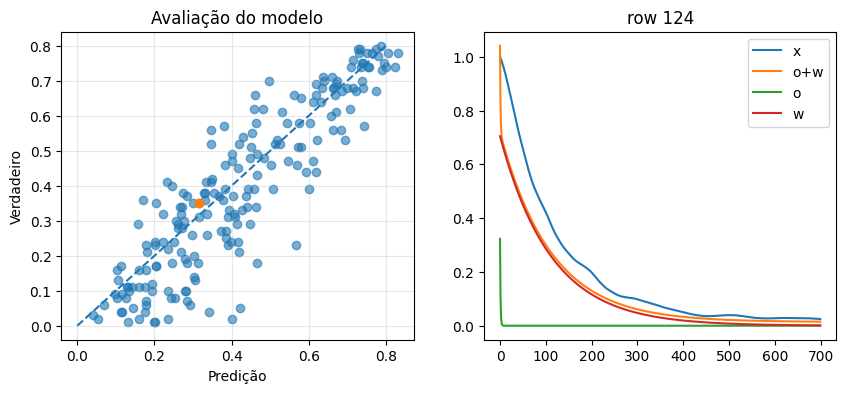

In [229]:
fig,ax = plt.subplots(1,2,figsize=(10,4))

ax[0].scatter(y_predPINN, yval, alpha=0.6)
ax[0].plot([0, .8], [0, .8], '--')

ax[0].set_xlabel("Predição");ax[0].set_ylabel("Verdadeiro");ax[0].set_title(f"Avaliação do modelo");
j = np.random.randint(0,200)
ax[0].scatter([y_predPINN[j]], [yval[j]])
ax[0].grid(True, alpha=0.3);


x_reconstr = y_param_pred[j,0]*np.exp(-np.arange(700)/y_param_pred[j,2]) + \
             y_param_pred[j,1]*np.exp(-np.arange(700)/y_param_pred[j,3]) + y_param_pred[j,4]
x_reconstr_o = y_param_pred[j,0]*np.exp(-np.arange(700)/y_param_pred[j,2])
x_reconstr_w = y_param_pred[j,1]*np.exp(-np.arange(700)/y_param_pred[j,3])
print(f"j:{j}, parameters: {y_param_pred[j]}, y_hat:{y_param_pred[j,0]/(y_param_pred[j,0]+y_param_pred[j,1]):.3f}, y true: {yval[j]:.3f}")
ax[1].plot(Xval[j].squeeze().detach().cpu().numpy(), label="x")
ax[1].plot(x_reconstr, label="o+w")
ax[1].plot(x_reconstr_o, label="o")
ax[1].plot(x_reconstr_w, label="w")
ax[1].set_title(f'row {j}')
ax[1].legend();

plt.show()

Correlation with good previous result: 0.9810169747560569


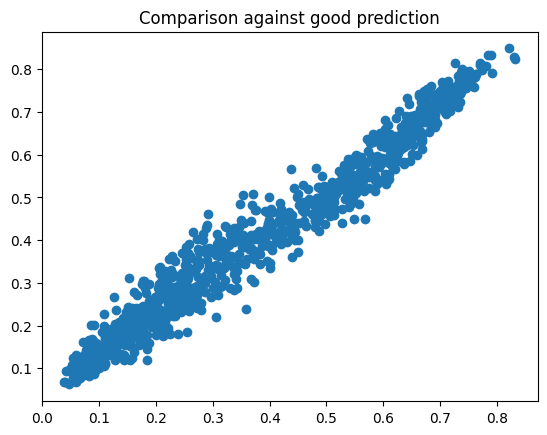

In [9]:
y_good = pd.read_csv('submissions/time2_trilha1_DWTcurva_PCA.csv', sep='\t').drop('CPMG', axis=1)

Xtest = torch.Tensor(np.array(test_df)).to(device)
headlessmodel.eval()
with torch.no_grad():
    pre_outcome_val = headlessmodel(Xtest)
    outp1_val = nn.Sigmoid()(pre_outcome_val[:,:3])
    outp2_val = nn.ReLU()   (pre_outcome_val[:,3:])
    y_param_testpred = torch.cat([outp1_val,outp2_val],dim=1).squeeze().detach().cpu().numpy()
 
ytest_predPINN = y_param_testpred[:,0]/(y_param_testpred[:,0]+y_param_testpred[:,1])

plt.scatter(y_good, ytest_predPINN)
plt.title('Comparison against good prediction')
print("Correlation with good previous result:",np.corrcoef(np.array(y_good).reshape(-1,), ytest_predPINN)[0,-1]);
# write_csv_file(ytest_predPINN)
# print("csv saved");

PINN using Laplace transform of two Gaussians

In [148]:
headlessmodel = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,6), #interpreted as A_o, A_w, sqrt(2)*sigma_o, sqrt(2)*sigma_w, 1/T2_o, 1/T2_w
    ).to(device)

optimizer = torch.optim.Adam(headlessmodel.parameters(), lr=1e-3)

Epoch 00 | train output MSE: 0.052792 | train fit MSE: 0.060761 | val output MSE: 0.044711 | val fit MSE: 0.061755
Epoch 10 | train output MSE: 0.015602 | train fit MSE: 0.014474 | val output MSE: 0.015896 | val fit MSE: 0.014072
Epoch 20 | train output MSE: 0.012792 | train fit MSE: 0.003153 | val output MSE: 0.011965 | val fit MSE: 0.003190
Epoch 30 | train output MSE: 0.010499 | train fit MSE: 0.002857 | val output MSE: 0.010256 | val fit MSE: 0.002890
Epoch 40 | train output MSE: 0.009843 | train fit MSE: 0.002687 | val output MSE: 0.011254 | val fit MSE: 0.002764
Epoch 50 | train output MSE: 0.009117 | train fit MSE: 0.002494 | val output MSE: 0.009040 | val fit MSE: 0.002557
Epoch 60 | train output MSE: 0.008668 | train fit MSE: 0.002330 | val output MSE: 0.008742 | val fit MSE: 0.002370
Epoch 70 | train output MSE: 0.009400 | train fit MSE: 0.001633 | val output MSE: 0.008802 | val fit MSE: 0.001655


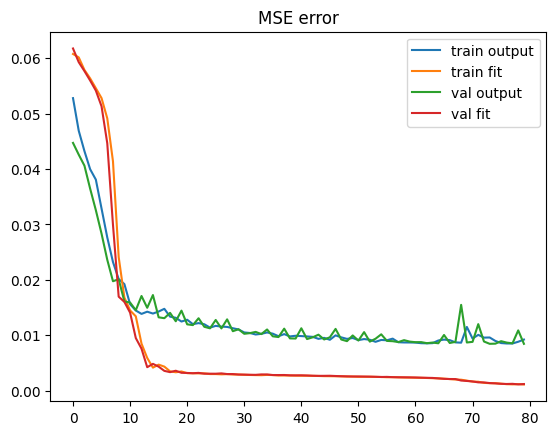

In [149]:
epochs = 80
history = []
for epoch in range(epochs):
    headlessmodel.train()
    train_loss_output, train_loss_phys = 0., 0.
        
    for xb, yb in train_loader:
        pre_outcome = headlessmodel(xb)
        outp1 = nn.Sigmoid()(pre_outcome[:,:2])
        outp2 = nn.functional.softplus(pre_outcome[:,2:])
        outcome = torch.cat([outp1,outp2],dim=1)
        outcome_ext = outcome.unsqueeze(1).expand(*xb.shape,outcome.shape[-1])
        
        t_values = torch.arange(0,xb.shape[1]).unsqueeze(0).expand(xb.shape).to(device)
        loss_output = nn.MSELoss()(outcome[:,0]*torch.erfc(- outcome[:,4]/outcome[:,2])/ \
                                   ( outcome[:,0]*torch.erfc(- outcome[:,4]/outcome[:,2]) + outcome[:,1]*torch.erfc(- outcome[:,5]/outcome[:,3]))
                                                          ,yb.squeeze())
        loss_phys   = nn.MSELoss()(xb, 
                       outcome_ext[:,:,0]*torch.exp(-outcome_ext[:,:,4]**2/torch.clamp(outcome_ext[:,:,2], min=1e-3)**2)*\
                       torch.special.erfcx(outcome_ext[:,:,2]*t_values/2 - outcome_ext[:,:,4]/torch.clamp(outcome_ext[:,:,2], min=1e-3)) + \
                       outcome_ext[:,:,1]*torch.exp(-outcome_ext[:,:,5]**2/torch.clamp(outcome_ext[:,:,3], min=1e-3)**2)*\
                       torch.special.erfcx(outcome_ext[:,:,3]*t_values/2 - outcome_ext[:,:,5]/torch.clamp(outcome_ext[:,:,3], min=1e-3))
                                  ) 
        
        optimizer.zero_grad()
        (loss_output+loss_phys).backward()
        optimizer.step()

        train_loss_output += loss_output.item() * xb.size(0)
        train_loss_phys += loss_phys.item() * xb.size(0)
    train_loss_output /=len(train_loader.dataset)
    train_loss_phys /=len(train_loader.dataset)

    headlessmodel.eval()
    val_loss_output, val_loss_phys = 0., 0.
    with torch.no_grad():
        for xb, yb in val_loader:
            pre_outcome = headlessmodel(xb)
            outp1 = nn.Sigmoid()(pre_outcome[:,:2])
            outp2 = nn.functional.softplus(pre_outcome[:,2:])
            outcome = torch.cat([outp1,outp2],dim=1)
            outcome_ext = outcome.unsqueeze(1).expand(*xb.shape,outcome.shape[-1])

            t_values = torch.arange(0,xb.shape[1]).unsqueeze(0).expand(xb.shape).to(device)
            loss_output = nn.MSELoss()(outcome[:,0]*torch.erfc(- outcome[:,4]/outcome[:,2])/ \
                                   ( outcome[:,0]*torch.erfc(- outcome[:,4]/outcome[:,2]) + outcome[:,1]*torch.erfc(- outcome[:,5]/outcome[:,3]))
                                                          ,yb.squeeze())
            loss_phys   = nn.MSELoss()(xb, 
                           outcome_ext[:,:,0]*torch.exp(-outcome_ext[:,:,4]**2/torch.clamp(outcome_ext[:,:,2], min=1e-3)**2)*\
                           torch.special.erfcx(outcome_ext[:,:,2]*t_values/2 - outcome_ext[:,:,4]/torch.clamp(outcome_ext[:,:,2], min=1e-3)) + \
                           outcome_ext[:,:,1]*torch.exp(-outcome_ext[:,:,5]**2/torch.clamp(outcome_ext[:,:,3], min=1e-3)**2)*\
                           torch.special.erfcx(outcome_ext[:,:,3]*t_values/2 - outcome_ext[:,:,5]/torch.clamp(outcome_ext[:,:,3], min=1e-3))
                                          )
            
            val_loss_output += loss_output.item() * xb.size(0)
            val_loss_phys += loss_phys.item() * xb.size(0)
        val_loss_output /=len(val_loader.dataset)
        val_loss_phys /=len(val_loader.dataset)

    history.append((train_loss_output,train_loss_phys, val_loss_output, val_loss_phys))

    if epoch%10==0: print(f"Epoch {epoch:02d} | train output MSE: {train_loss_output:.6f} | train fit MSE: {train_loss_phys:.6f}",
                            f"| val output MSE: {val_loss_output:.6f} | val fit MSE: {val_loss_phys:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train output')
plt.plot(range(len(history)), [l[1] for l in history], label='train fit')
plt.plot(range(len(history)), [l[2] for l in history], label='val output')
plt.plot(range(len(history)), [l[3] for l in history], label='val fit')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.16110185 R²: 0.50253224


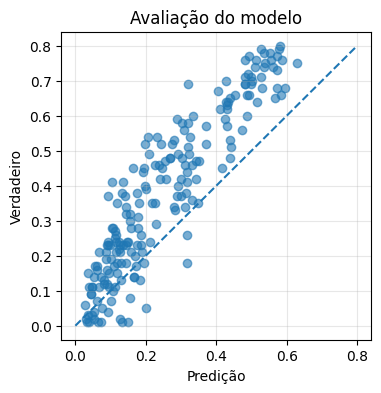

In [150]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

headlessmodel.eval()
with torch.no_grad():
    pre_outcome_val = headlessmodel(Xval)
    outp1_val = nn.Sigmoid()(pre_outcome_val[:,:3])
    outp2_val = nn.functional.softplus(pre_outcome_val[:,3:])
    y_param_pred = torch.cat([outp1_val,outp2_val],dim=1).squeeze().detach().cpu().numpy()
    # y_param_pred = nn.Sigmoid()(pre_outcome_val).squeeze().detach().cpu().numpy()
 
y_predPINN = y_param_pred[:,0]/(y_param_pred[:,0]+y_param_pred[:,1])

# RMSE, R2, MAE
mse = np.mean((y_predPINN-yval)**2)
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2)

plt.figure(figsize=(4,4))
plt.scatter(y_predPINN, yval, alpha=0.6)
plt.plot([0, .8], [0, .8], '--')

plt.xlabel("Predição");plt.ylabel("Verdadeiro");plt.title(f"Avaliação do modelo");
plt.grid(True, alpha=0.3);plt.show()

j:41, A_o+A_w: 0.9378077387809753 parameters: [9.0190820e-02 8.4761691e-01 1.6035212e-03 2.8251527e-02 7.2385380e-03 6.8101275e-05]
1.9999943 2.0


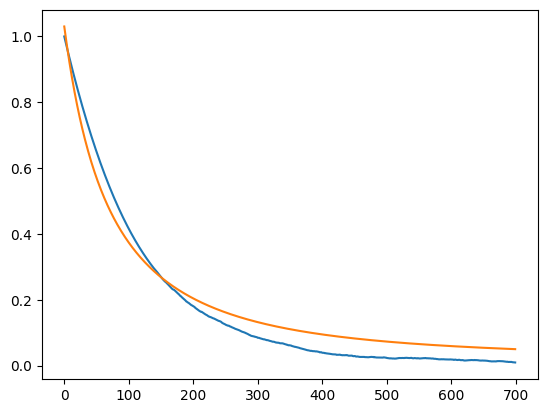

In [157]:
from scipy.special import erfc, erfcx

j = np.random.randint(0,200)
# x_reconstr = y_param_pred[j,0]*np.exp(-np.arange(700)/y_param_pred[j,3]) + \
#              y_param_pred[j,1]*np.exp(-np.arange(700)/y_param_pred[j,4]) + y_param_pred[j,2]
# x_reconstr = y_param_pred[j,0]*np.exp(-np.arange(700)/500) + \
#              y_param_pred[j,1]*np.exp(-np.arange(700)/25000) #+ y_param_pred[j,2]
# x_reconstr = y_param_pred[j]*np.exp(-np.arange(700)/500) + \
#              (1-y_param_pred[j])*np.exp(-np.arange(700)/25000) #+ y_param_pred[j,2]
t_as_np = t_values.squeeze().detach().cpu().numpy()[0]
x_reconstr = y_param_pred[j,0]*np.exp(-y_param_pred[j,4]**2/y_param_pred[j,2]**2)*\
                       erfcx(y_param_pred[j,2]*t_as_np/2 - y_param_pred[j,4]/y_param_pred[j,2]) + \
             y_param_pred[j,1]*np.exp(-y_param_pred[j,5]**2/y_param_pred[j,3]**2)*\
                       erfcx(y_param_pred[j,3]*t_as_np/2 - y_param_pred[j,5]/y_param_pred[j,3])

print(f"j:{j}, A_o+A_w: {y_param_pred[j,0]+y_param_pred[j,1]} parameters: {y_param_pred[j]}")
print(np.exp(-y_param_pred[j,4]**2/y_param_pred[j,2]**2)* erfcx(- y_param_pred[j,4]/y_param_pred[j,2]), 
     erfc(- y_param_pred[j,4]/y_param_pred[j,2]))
plt.plot(Xval[j].squeeze().detach().cpu().numpy())
plt.plot(x_reconstr);

Correlation with good previous result: 0.9843720052423758


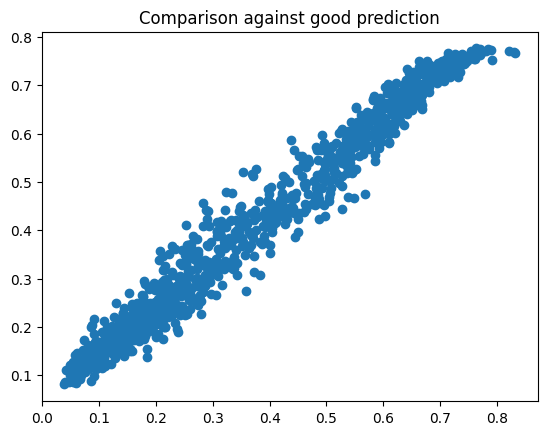

In [30]:
y_good = pd.read_csv('submissions/time2_trilha1_DWTcurva_PCA.csv', sep='\t').drop('CPMG', axis=1)

Xtest = torch.Tensor(np.array(test_df)).to(device)
headlessmodel.eval()
with torch.no_grad():
    pre_outcome_val = headlessmodel(Xtest)
    outp1_val = nn.Sigmoid()(pre_outcome_val[:,:3])
    outp2_val = nn.ReLU()   (pre_outcome_val[:,3:])
    y_param_testpred = torch.cat([outp1_val,outp2_val],dim=1).squeeze().detach().cpu().numpy()
 
ytest_predPINN = y_param_testpred[:,0]/(y_param_testpred[:,0]+y_param_testpred[:,1])

plt.scatter(y_good, ytest_predPINN)
plt.title('Comparison against good prediction')
print("Correlation with good previous result:", np.corrcoef(np.array(y_good).reshape(-1,), ytest_predPINN)[0,-1]);
# write_csv_file(ytest_predPINN)
# print("csv saved");

Simple MLP with dropout

In [199]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df.iloc[:,:-1])).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

trainDs, valDs = random_split(TensorDataset(X, y), [.8,.2])
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

Device is cuda


In [200]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.Dropout(.2),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.Dropout(.2),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.056744 | Val MSE: 0.050650
Epoch 10 | Train MSE: 0.018253 | Val MSE: 0.017925
Epoch 20 | Train MSE: 0.013069 | Val MSE: 0.013832
Epoch 30 | Train MSE: 0.011572 | Val MSE: 0.011387
Epoch 40 | Train MSE: 0.009867 | Val MSE: 0.011315
Epoch 50 | Train MSE: 0.009462 | Val MSE: 0.010157
Epoch 60 | Train MSE: 0.009240 | Val MSE: 0.011023
Epoch 70 | Train MSE: 0.009076 | Val MSE: 0.009746
Epoch 80 | Train MSE: 0.009022 | Val MSE: 0.009677
Epoch 90 | Train MSE: 0.008869 | Val MSE: 0.011711


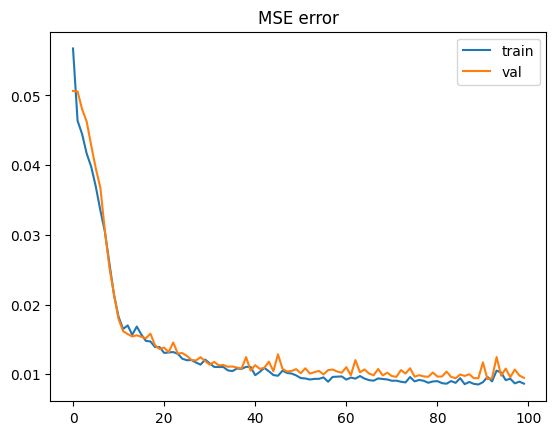

In [201]:
epochs = 100  #20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%10==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.0974482 R²: 0.8373903 MAE: 0.07398458


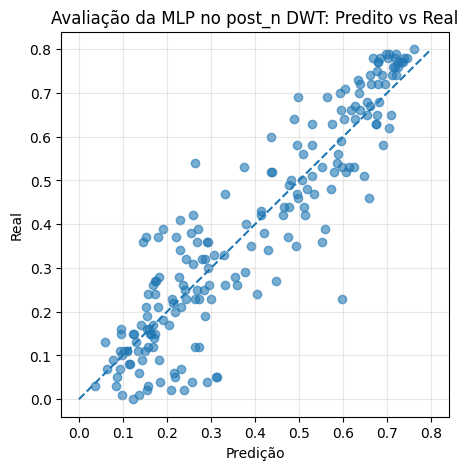

In [202]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(y_pred, yval, alpha=0.6)
plt.plot([0, .8], [0, .8], '--')

plt.xlabel("Predição")
plt.ylabel("Real")
plt.title(f"Avaliação da MLP no post_n DWT: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

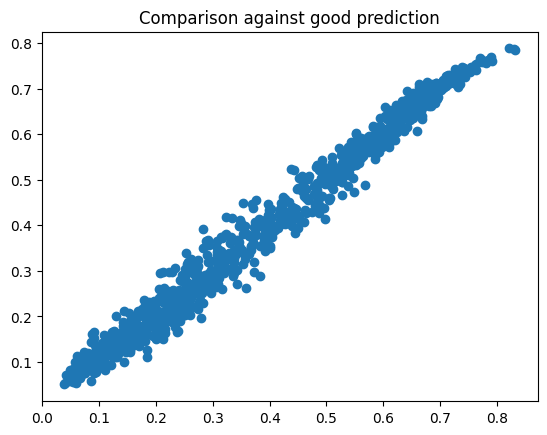

In [18]:
Xtest = torch.Tensor(np.array(test_df)).to(device)
model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()

plt.scatter(y_good, ytest_pred)
plt.title('Comparison against good prediction');
# write_csv_file(ytest_pred)
# print("csv saved");

RMSE: 0.10062174 R²: 0.82662666 MAE: 0.076439306


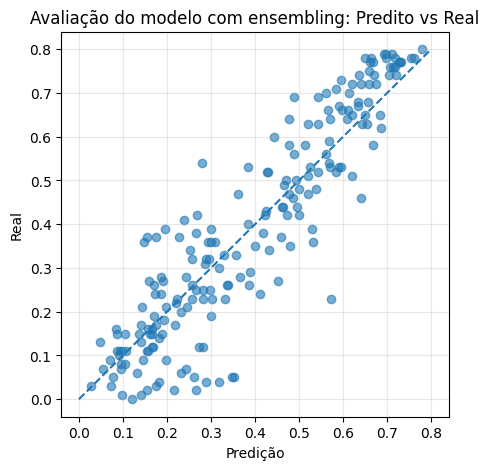

In [205]:
y_ensembled = (y_pred+y_predPINN)/2

# RMSE, R2, MAE
mse = np.mean((y_ensembled - yval)**2)
mae = np.mean(np.abs((y_ensembled - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(y_ensembled, yval, alpha=0.6)
plt.plot([0, .8], [0, .8], '--')

plt.xlabel("Predição")
plt.ylabel("Real")
plt.title(f"Avaliação do modelo com ensembling: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

### Fazendo PCA

In [161]:
train_df = pd.read_csv('data_train_post_n_smoothing.csv', sep="\t")
test_df = pd.read_csv('data_test_post_n_smoothing.csv', sep="\t")

In [162]:
pca = sklearn.decomposition.PCA(n_components=.999)
pca.fit(train_df.iloc[:,:-1])

,n_components,0.999
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [163]:
train_df_pca = pd.DataFrame(pca.transform(train_df.iloc[:,:-1]))
train_df_pca['y'] = train_df['y']
test_df_pca = pd.DataFrame(pca.transform(test_df))
# train_df_pca.to_csv("data_train_PCA.csv", sep="\t")
# test_df_pca.to_csv("data_test_PCA.csv", sep="\t")
train_df_pca

,0,1,2,3,4,5,6,7,8,9,10,y
0,0.444431,0.082405,-0.040294,0.124236,-0.084919,-0.025837,0.080508,-0.067838,0.041027,0.015938,0.005446,0.29
1,0.341688,0.107980,-0.015460,-0.057992,0.062588,0.022127,-0.013762,0.022489,0.053635,0.008734,-0.042154,0.30
2,1.077045,0.345204,-0.024039,-0.021560,-0.070621,0.073333,0.048505,0.009087,0.001892,0.036204,0.001538,0.11
3,-1.013654,0.093226,-0.075131,-0.039342,-0.215066,0.016645,-0.095225,0.045525,0.034300,0.053545,-0.001041,0.61
4,-1.169581,-0.206264,0.055381,-0.038263,0.021175,0.067620,-0.050947,-0.000804,-0.003702,0.023894,0.017694,0.74
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.324731,0.002221,0.035492,-0.004576,-0.033421,-0.038830,0.056632,0.028731,0.018639,0.014455,0.024475,0.33
996,-0.455841,0.102950,-0.113884,0.038986,0.048370,0.037442,-0.023385,-0.013549,0.051196,-0.011123,0.017136,0.29
997,-0.108774,-0.181847,-0.201961,0.066019,0.070908,-0.174754,0.042541,-0.026335,0.024345,0.054058,0.043532,0.36
998,-0.917622,0.049751,-0.139893,-0.017946,-0.076690,-0.027752,-0.022502,0.076150,-0.026749,-0.015698,-0.002394,0.69


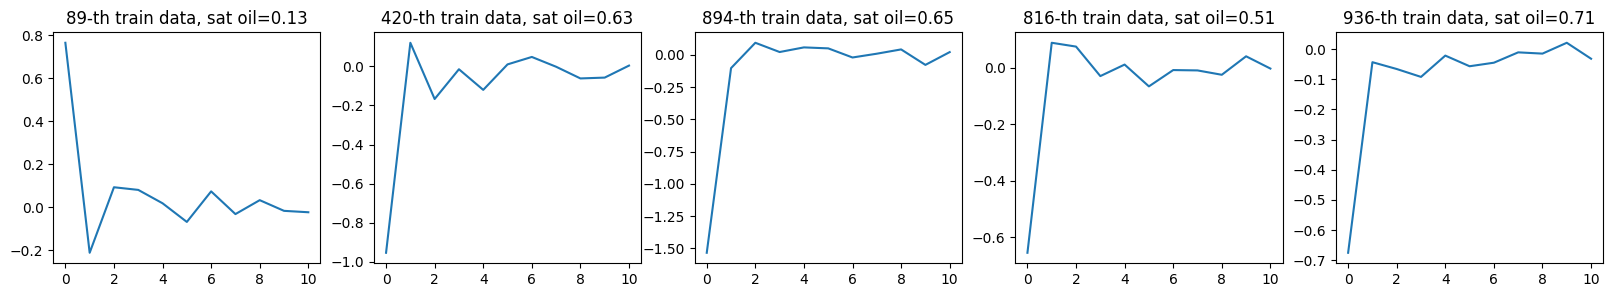

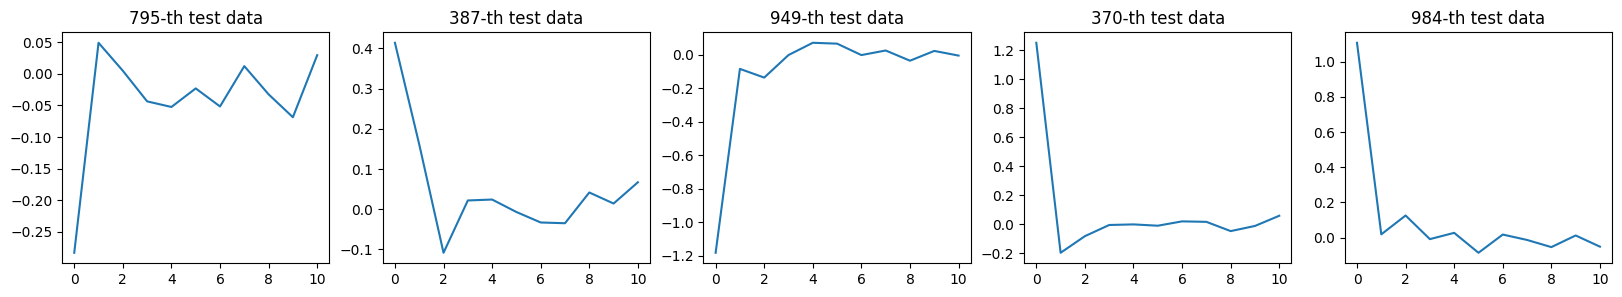

In [164]:
'''Plot graph of test and train after PCA'''
# set_seed(seed)
fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_df_pca.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th train data, sat oil={train_df_pca.iloc[j,-1]}")
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_df_pca.loc[j].values)
    ax[i].set_title(f"{j}-th test data")
plt.show();

simple MLP model

In [209]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df_pca.iloc[:,:-1])).to(device)
y = torch.Tensor(np.array(train_df_pca['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)

Device is cuda


In [220]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    # nn.ReLU(),
    # nn.Linear(128,32),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.055215 | Val MSE: 0.034209
Epoch 05 | Train MSE: 0.011071 | Val MSE: 0.012346
Epoch 10 | Train MSE: 0.009311 | Val MSE: 0.009829
Epoch 15 | Train MSE: 0.008483 | Val MSE: 0.009101
Epoch 20 | Train MSE: 0.007846 | Val MSE: 0.008625
Epoch 25 | Train MSE: 0.007603 | Val MSE: 0.008477
Epoch 30 | Train MSE: 0.007490 | Val MSE: 0.008496


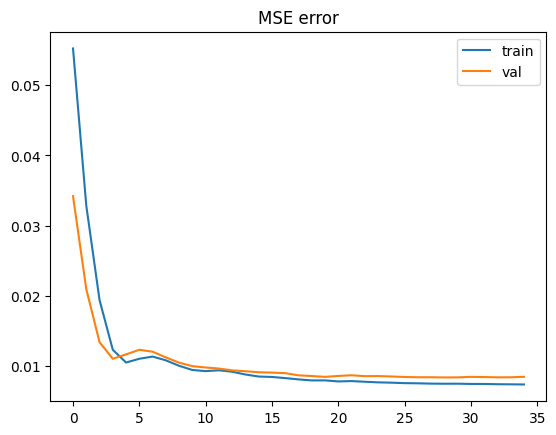

RMSE: 0.09221955 R²: 0.8187233 MAE: 0.071108714


In [221]:
epochs = 35
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

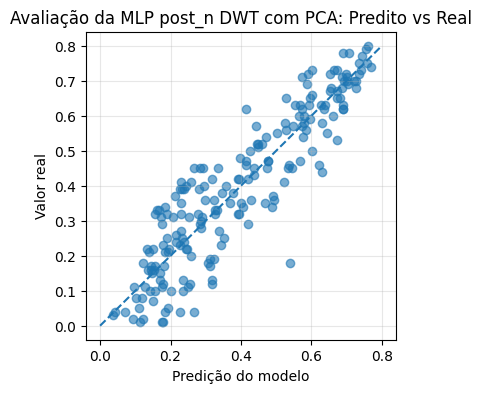

In [217]:
# Gráfico de avaliação
plt.figure(figsize=(4,4))
plt.scatter(y_pred, yval, alpha=0.6)

plt.plot([0, .8], [0, .8], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da MLP post_n DWT com PCA: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

csv saved


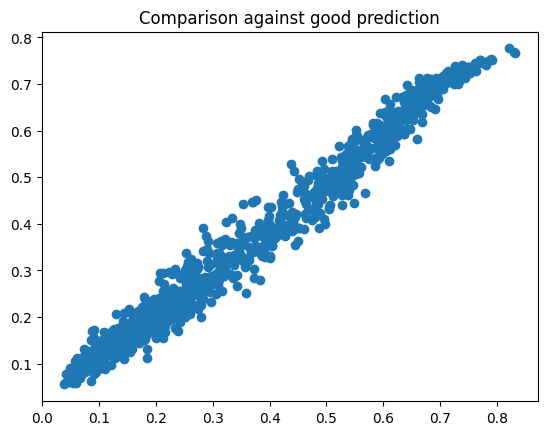

In [62]:
y_good = pd.read_csv('submissions/time2_trilha1_DWTcurva_PCA.csv', sep='\t').drop('CPMG', axis=1)

Xtest = torch.Tensor(np.array(test_df)).to(device)
model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()

plt.scatter(y_good, ytest_pred)
plt.title('Comparison against good prediction');
write_csv_file(ytest_pred)
print("csv saved");

RMSE: 0.16302463 R²: 0.4334967 MAE: 0.1337521


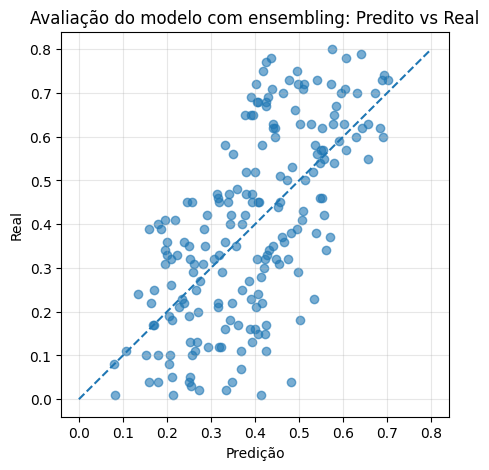

In [222]:
y_ensembled = (y_pred+y_predPINN)/2

# RMSE, R2, MAE
mse = np.mean((y_ensembled - yval)**2)
mae = np.mean(np.abs((y_ensembled - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(y_ensembled, yval, alpha=0.6)
plt.plot([0, .8], [0, .8], '--')

plt.xlabel("Predição")
plt.ylabel("Real")
plt.title(f"Avaliação do modelo com ensembling: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

With Dropout

In [90]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df_pca.iloc[:,:-1])).to(device)
y = torch.Tensor(np.array(train_df_pca['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)

Device is cuda


In [93]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.Dropout(.2),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.Dropout(.2),
    # nn.ReLU(),
    # nn.Linear(128,32),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.058920 | Val MSE: 0.044475
Epoch 05 | Train MSE: 0.011554 | Val MSE: 0.014753
Epoch 10 | Train MSE: 0.009637 | Val MSE: 0.010676
Epoch 15 | Train MSE: 0.008729 | Val MSE: 0.009483


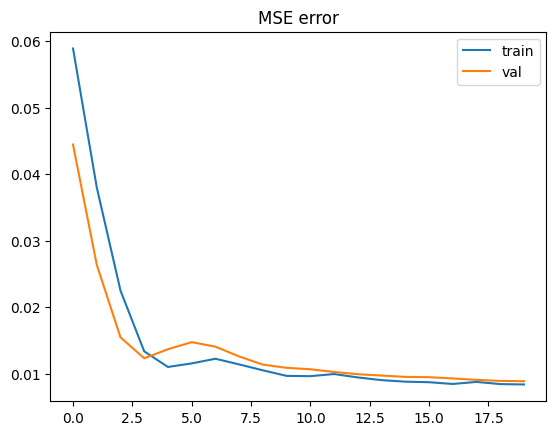

RMSE: 0.09422768 R²: 0.8240136 MAE: 0.07225994


In [94]:
epochs = 20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

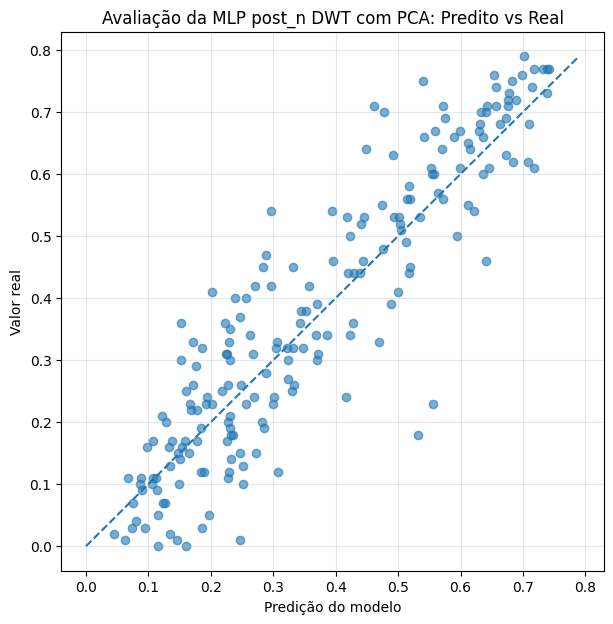

In [95]:
# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da MLP post_n DWT com PCA: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

csv saved


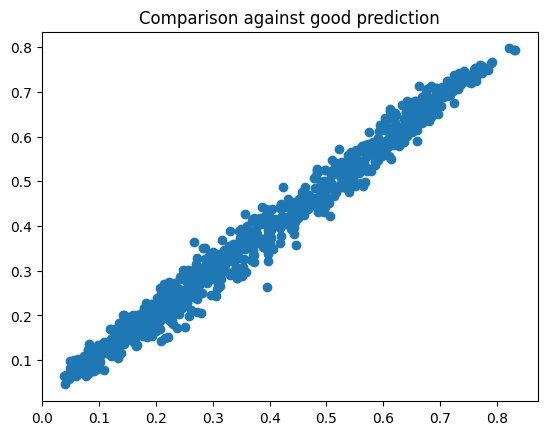

In [96]:
y_good = pd.read_csv('submissions/time2_trilha1_DWTcurva_PCA.csv', sep='\t').drop('CPMG', axis=1)

Xtest = torch.Tensor(np.array(test_df_pca)).to(device)
model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()

plt.scatter(y_good, ytest_pred)
plt.title('Comparison against good prediction');
write_csv_file(ytest_pred)
print("csv saved");

Agora com CatBoost

In [51]:
%pip install catboost

  Using cached catboost-1.2.8-cp310-cp310-manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.4.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached narwhals-2.11.0-py3-none-any.whl.metadata (11 kB)
Using cached catboost-1.2.8-cp310-cp310-manylinux2014_x86_64.whl (99.2 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-6.4.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.11.0-py3-none-any.whl (423 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]
Note: you may need to restart the kernel to use updated packages.


## Catboost: training setup

In [40]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

n_init_points = 500
X = np.array(train_df.iloc[:,:n_init_points])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

model = CatBoostRegressor()
model.fit(Xtrain,ytrain, verbose=0, eval_set=(Xval,yval))

[(1000, 500), (1000,), (800, 500), (200, 500), (800,), (200,)]


RMSE: 0.09839301421004155 R²: 0.8155809803197289 MAE: 0.07921258220582261


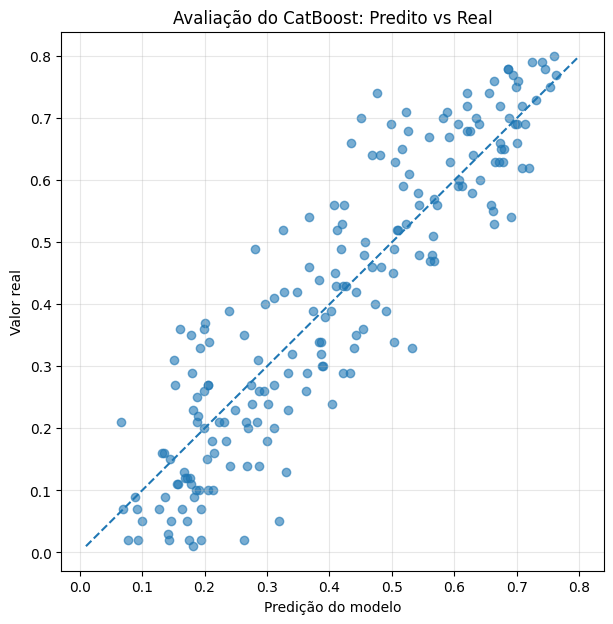

In [41]:
y_pred = model.predict(Xval)

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do CatBoost: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [196]:
Xtest = np.array(short_test_df.iloc[:,:n_init_points])
write_csv_file(model.predict(Xtest))

,CPMG,%
0,CPMG_000.csv,0.274665
1,CPMG_001.csv,0.669553
2,CPMG_002.csv,0.183837
3,CPMG_003.csv,0.434456
4,CPMG_004.csv,0.072703
...,...,...
995,CPMG_995.csv,0.242696
996,CPMG_996.csv,0.748017
997,CPMG_997.csv,0.209394
998,CPMG_998.csv,0.225531


## Agora uma CNN, por favor

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = torch.Tensor(np.array(train_df)[:,:-1]).unsqueeze(1).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [37]:
model = nn.Sequential(
    nn.Conv1d(1,4,5),
    nn.ReLU(),
    nn.AvgPool1d(4),

    nn.Conv1d(4,16,5),
    nn.ReLU(),
    nn.MaxPool1d(4),

    nn.Conv1d(16,4,5),
    nn.ReLU(),
    nn.MaxPool1d(4),
    
    nn.Flatten(),
    nn.Linear(36,64),
    nn.ReLU(),

    nn.Linear(64,8),
    nn.ReLU(),
        
    nn.Linear(8,1),
    nn.Sigmoid()
).to(device)

#to get the size right in the linear layer
# x = torch.randn(1000, 1, 2201)
# out = model(X)
# print(out.shape)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 04 | Train MSE: 0.052991 | Val MSE: 0.051380
Epoch 09 | Train MSE: 0.052487 | Val MSE: 0.050464
Epoch 14 | Train MSE: 0.050430 | Val MSE: 0.047446
Epoch 19 | Train MSE: 0.043019 | Val MSE: 0.038365
Epoch 24 | Train MSE: 0.021443 | Val MSE: 0.016534
Epoch 29 | Train MSE: 0.011996 | Val MSE: 0.013027
Epoch 34 | Train MSE: 0.013003 | Val MSE: 0.012295
Epoch 39 | Train MSE: 0.011684 | Val MSE: 0.011743
Epoch 44 | Train MSE: 0.011024 | Val MSE: 0.011776
Epoch 49 | Train MSE: 0.010940 | Val MSE: 0.011763
Epoch 54 | Train MSE: 0.010799 | Val MSE: 0.011605
Epoch 59 | Train MSE: 0.010706 | Val MSE: 0.011517
Epoch 64 | Train MSE: 0.010821 | Val MSE: 0.011479
Epoch 69 | Train MSE: 0.011143 | Val MSE: 0.011357
Epoch 74 | Train MSE: 0.010484 | Val MSE: 0.011497
Epoch 79 | Train MSE: 0.010518 | Val MSE: 0.011737
Epoch 84 | Train MSE: 0.010432 | Val MSE: 0.011258
Epoch 89 | Train MSE: 0.010354 | Val MSE: 0.011117
Epoch 94 | Train MSE: 0.010673 | Val MSE: 0.011077
Epoch 99 | Train MSE: 0.010583 

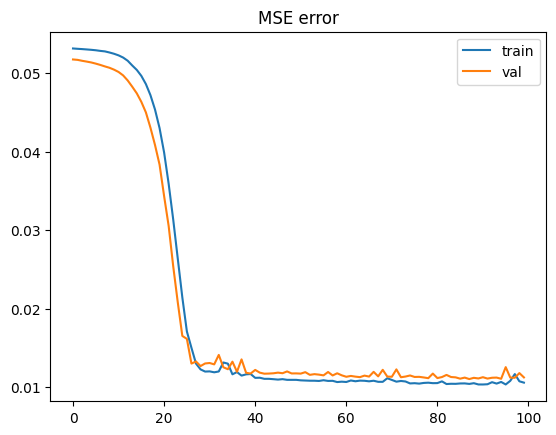

In [38]:
epochs = 100
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if (epoch+1)%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.10606897 R²: 0.77820325 MAE: 0.07908359


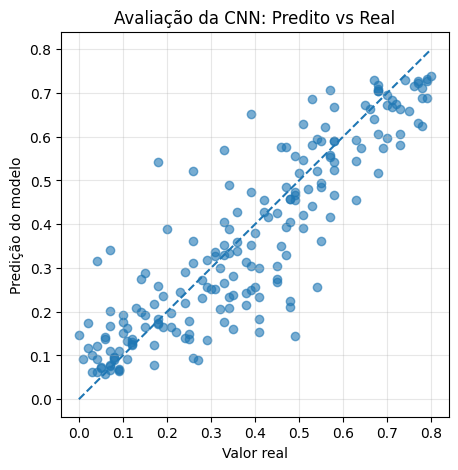

In [39]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()
# print(Xval.shape, yval.shape)

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Valor real")
plt.ylabel("Predição do modelo")
plt.title("Avaliação da CNN: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

## RNN: GRU

In [79]:
train_df = pd.read_csv('data_train_DWT.csv', sep="\t")
test_df = pd.read_csv('data_test_DWT.csv', sep="\t")

In [80]:
X = torch.Tensor(np.array(train_df)[:,:-1]).unsqueeze(2)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
X.shape

torch.Size([1000, 2202, 1])

In [81]:
hidden_size = 16
gru = nn.GRU(input_size=1, hidden_size=hidden_size, num_layers=2, batch_first=True)
head = nn.Linear(hidden_size, 1)   # prediction head

# combine params from both "submodules"
optimizer = torch.optim.Adam(list(gru.parameters()) + list(head.parameters()), lr=1e-3)
criterion = nn.MSELoss()

epoch 01 | train MSE: 0.065550
epoch 02 | train MSE: 0.061722
epoch 03 | train MSE: 0.058463
epoch 04 | train MSE: 0.055820
epoch 05 | train MSE: 0.054288
epoch 06 | train MSE: 0.053327
epoch 07 | train MSE: 0.053487
epoch 08 | train MSE: 0.053595
epoch 09 | train MSE: 0.053774
epoch 10 | train MSE: 0.053770


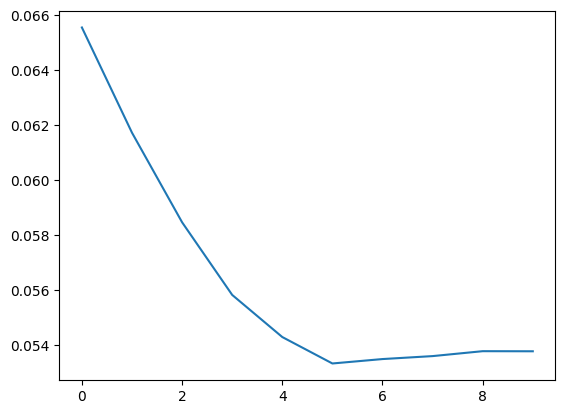

In [82]:
# ----- training loop -----
gru.train(); head.train()
loss_history = []
for epoch in range(10):
    train_loss = 0.0
    for xb, yb in train_loader:
        # forward (manual “forward”)
        out, h = gru(xb)               # out: (B, T, H), h: (1, B, H)
        feat = out[:, -1, :]           # OR: h[-1]  (both are (B, H))
        pred = torch.sigmoid(head(feat))  # keep in [0,1]

        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        
    loss_history.append(train_loss/len(train_loader.dataset))
    print(f"epoch {epoch+1:02d} | train MSE: {train_loss/len(train_loader.dataset):.6f}")
plt.plot(loss_history);

RMSE: 0.23506692 MAE: 0.2033291


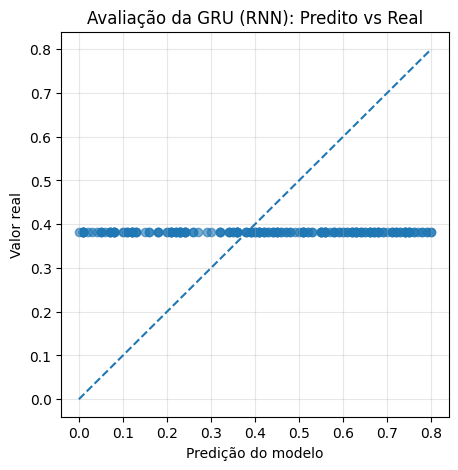

In [83]:
# ----- inference -----
gru.eval(); head.eval()
val_loss = 0
with torch.no_grad():
    for xb, yb in val_loader:
        out, h = gru(xb)
        feat = out[:, -1, :]
        y_pred = torch.sigmoid(head(feat))
        val_loss += criterion(y_pred, yb).item() * xb.size(0)
val_loss /= len(val_loader.dataset)

# RMSE, MAE
rmse = np.sqrt(np.mean((y_pred.squeeze().detach().cpu().numpy() - yval.reshape(-1,1))**2))
mae = np.mean(np.abs((y_pred.squeeze().detach().cpu().numpy() - yval.reshape(-1,1))))
print("RMSE:", rmse, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da GRU (RNN): Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

Horrível, RNN não funciona

## Random Forest

In [14]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.model_selection import train_test_split

X = np.array(train_df.iloc[:,:-1])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

[(1000, 700), (1000,), (800, 700), (200, 700), (800,), (200,)]


In [15]:
model = RFR(n_estimators=100, criterion='squared_error')
model.fit(Xtrain, ytrain)
y_pred, y_tr_pred = model.predict(Xval), model.predict(Xtrain)

RMSE: 0.09185919496707991 R²: 0.8434087867329396 MAE: 0.073049


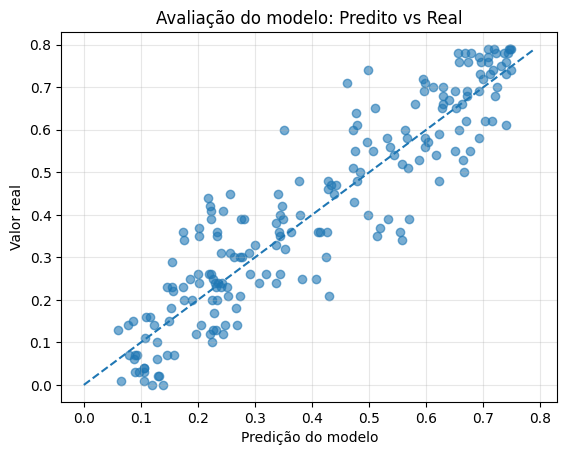

In [16]:
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
print("RMSE:", np.sqrt(mse), "R²:", 1-mse/np.std(yval)**2,"MAE:", mae)

# Gráfico de avaliação
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())

plt.scatter(y_pred, yval, alpha=0.6)
plt.plot([min_val, max_val], [min_val, max_val], '--')
plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do modelo: Predito vs Real")
plt.grid(True, alpha=0.3)

plt.show()

,CPMG,%
0,CPMG_000.csv,0.3256
1,CPMG_001.csv,0.7264
2,CPMG_002.csv,0.1834
3,CPMG_003.csv,0.3779
4,CPMG_004.csv,0.1005
...,...,...
995,CPMG_995.csv,0.2994
996,CPMG_996.csv,0.7148
997,CPMG_997.csv,0.1999
998,CPMG_998.csv,0.1709


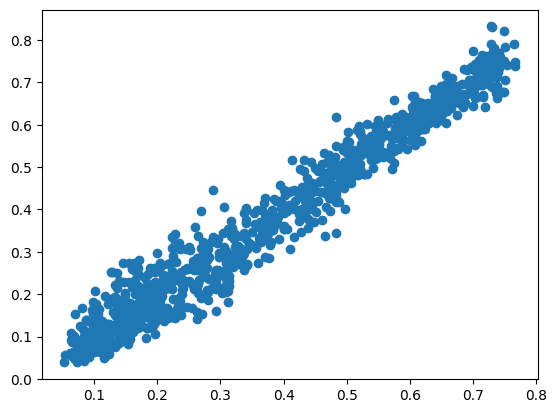

In [25]:
Xtest = np.array(test_df.iloc[:,:])
y_pred_test = model.predict(Xtest)

y_good = pd.read_csv('submissions/time2_trilha1_DWTcurva_PCA.csv', sep='\t').drop('CPMG', axis=1)

plt.scatter(y_pred_test,y_good)
write_csv_file(y_pred_test)

Resultado fraco

In [122]:
import subprocess

with open("requirements.txt", "w") as f:
    reqs = subprocess.check_output(["pip", "freeze"]).decode("utf-8")
    f.write(reqs)